In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import joblib

# Fetch raw stock details
ticker = "AAPL"
df = yf.download(ticker, start="2020-01-01", end="2026-01-01")

# Look at the first 5 rows inside the notebook cell
df.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333885,72.394093,71.091191,71.344062,135480400
2020-01-03,71.630653,72.389273,71.406681,71.563221,146322800
2020-01-06,72.201408,72.239942,70.503546,70.754014,118387200
2020-01-07,71.861832,72.466315,71.642674,72.211033,108872000
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200


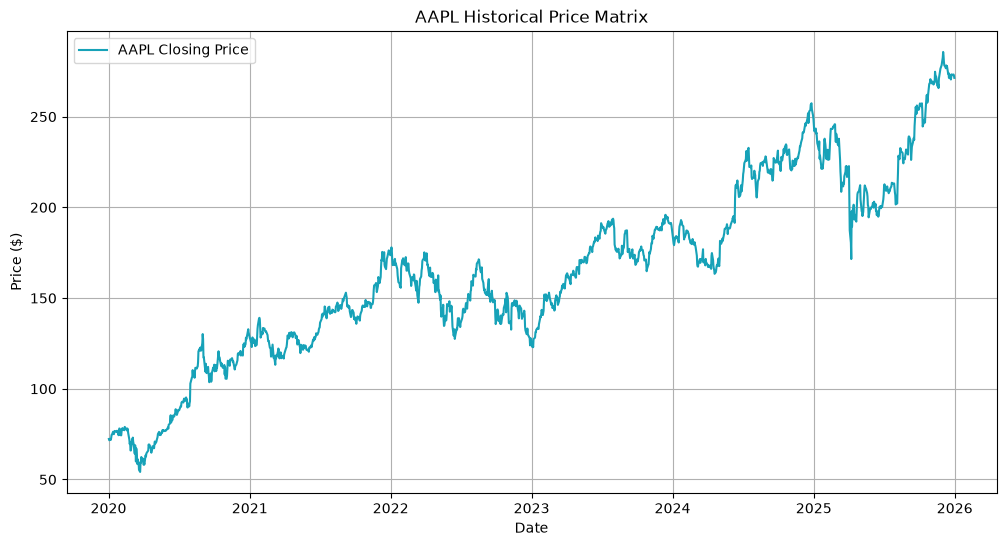

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label=f'{ticker} Closing Price', color='#17a2b8')
plt.title(f'{ticker} Historical Price Matrix')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show() # This renders an interactive chart right inside your notebook browser window!


[*********************100%***********************]  1 of 1 completed

⚡ Starting multi-ticker training sequence...

📥 Fetching data for: AAPL...
🚀 Model successfully generated and exported to AAPL_model.pkl!

📥 Fetching data for: TSLA...



[*********************100%***********************]  1 of 1 completed


🚀 Model successfully generated and exported to TSLA_model.pkl!

📥 Fetching data for: NVDA...


[*********************100%***********************]  1 of 1 completed

🚀 Model successfully generated and exported to NVDA_model.pkl!

🎉 Multi-ticker model training complete! All 3 files generated.


In [ ]:
#  DEEP LEARNING LSTM MODEL TRAINING PIPELINE 
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import yfinance as yf
import joblib

#  Expanded ticker registry matrix
tickers = ["AAPL", "TSLA", "NVDA", "MSFT", "AMZN"]
models_dir = "./ml_models"
os.makedirs(models_dir, exist_ok=True)

print("Initializing Advanced Multi-Feature LSTM Deep Learning Pipeline...")

for current_ticker in tickers:
    print(f"\nProcessing deep learning data for: {current_ticker}...")
    
    # Download data up to today for your cron job automation
    lstm_df = yf.download(current_ticker, start="2018-01-01")
    if lstm_df.empty:
        print(f"⚠️ Warning: No data fetched for {current_ticker}. Skipping.")
        continue
        
    # Flatten columns if multi-index headers occur from yfinance download arrays
    if isinstance(lstm_df.columns, pd.MultiIndex):
        lstm_df.columns = lstm_df.columns.get_level_values(0)
        
    # ENHANCEMENT 1: Calculate Technical Indicators
    # 20-Day Simple Moving Average
    lstm_df['SMA_20'] = lstm_df['Close'].rolling(window=20).mean()
    
    # 14-Day Relative Strength Index (RSI)
    delta = lstm_df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    lstm_df['RSI_14'] = 100 - (100 / (1 + rs))
    
    # Drop empty rolling window rows safely
    lstm_df = lstm_df.dropna()
    
    # Isolate our 3 deep learning features
    feature_cols = ['Close', 'SMA_20', 'RSI_14']
    feature_data = lstm_df[feature_cols].values
    
    # 1. Scale all three features independently between 0 and 1
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_features = scaler.fit_transform(feature_data)
    
    # 2. Build multi-feature sequence data: Look at past 30 days to predict next Close price
    prediction_days = 30
    X_lstm, y_lstm = [], []
    
    for x in range(prediction_days, len(scaled_features)):
        # Extract past 30 days for all 3 features (Close, SMA, RSI)
        X_lstm.append(scaled_features[x-prediction_days:x, :])
        # Target is strictly the Close price (column index 0) on the 31st day
        y_lstm.append(scaled_features[x, 0])
        
    X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)
    
    # 3D Matrix layout: [samples, time steps, features] -> features is now 3!
    X_lstm = np.reshape(X_lstm, (X_lstm.shape[0], X_lstm.shape[1], X_lstm.shape[2]))
    
    print(f"Compiling 3-Feature Neural Architecture for {current_ticker}...")
    # 3. Create the network layers layout with the new input shape
    model = Sequential([
        LSTM(units=50, return_sequences=True, input_shape=(X_lstm.shape[1], X_lstm.shape[2])),
        Dropout(0.2), 
        LSTM(units=50, return_sequences=False),
        Dropout(0.2),
        Dense(units=25),
        Dense(units=1) 
    ])
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    print(f"Training neural model (5 Epoch Matrix Passes)...")
    model.fit(X_lstm, y_lstm, epochs=5, batch_size=32, verbose=0)
    
    # 4. Package weights, feature counts, and standard data frames
    model_data = {
        'model_architecture': model.to_json(),     
        'model_weights': model.get_weights(),       
        'scaler': scaler,                           
        'last_30_days_scaled': scaled_features[-30:], # Seed rows containing all 3 features
        'last_price': float(lstm_df['Close'].iloc[-1])
    }
    
    filename = os.path.join(models_dir, f"{current_ticker}_lstm_model.pkl")
    joblib.dump(model_data, filename)
    print(f"Deep Learning model successfully generated and exported to {filename}!")

print("\nMulti-ticker LSTM deep learning training complete! All 5 production files generated.")


⚡ Initializing Advanced Multi-Feature LSTM Deep Learning Pipeline...

📥 Processing deep learning data for: AAPL...


[*********************100%***********************]  1 of 1 completed
e:\New folder (2)\stock-prediction-portal\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


🧠 Compiling 3-Feature Neural Architecture for AAPL...
🏋️ Training neural model (5 Epoch Matrix Passes)...
🚀 Deep Learning model successfully generated and exported to ./ml_models\AAPL_lstm_model.pkl!

📥 Processing deep learning data for: TSLA...


[*********************100%***********************]  1 of 1 completed
e:\New folder (2)\stock-prediction-portal\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


🧠 Compiling 3-Feature Neural Architecture for TSLA...
🏋️ Training neural model (5 Epoch Matrix Passes)...
🚀 Deep Learning model successfully generated and exported to ./ml_models\TSLA_lstm_model.pkl!

📥 Processing deep learning data for: NVDA...


...

🧠 Compiling 3-Feature Neural Architecture for NVDA...
🏋️ Training neural model (5 Epoch Matrix Passes)...
🚀 Deep Learning model successfully generated and exported to ./ml_models\NVDA_lstm_model.pkl!

📥 Processing deep learning data for: MSFT...


[*********************100%***********************]  1 of 1 completed
e:\New folder (2)\stock-prediction-portal\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


🧠 Compiling 3-Feature Neural Architecture for MSFT...
🏋️ Training neural model (5 Epoch Matrix Passes)...
🚀 Deep Learning model successfully generated and exported to ./ml_models\MSFT_lstm_model.pkl!

📥 Processing deep learning data for: AMZN...


[*********************100%***********************]  1 of 1 completed
e:\New folder (2)\stock-prediction-portal\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


🧠 Compiling 3-Feature Neural Architecture for AMZN...
🏋️ Training neural model (5 Epoch Matrix Passes)...
🚀 Deep Learning model successfully generated and exported to ./ml_models\AMZN_lstm_model.pkl!

🎉 Multi-ticker LSTM deep learning training complete! All 5 production files generated.
